# Data Cleaning & Quality Analysis — alexneakameni/ZSHOT-HARDSET-v2

Deep analysis of the HuggingFace dataset for text quality, label overrepresentation, duplicates, and contradictions.

**Goals:**
1. Load & overview the HF dataset
2. **Text cleaning** — detect malformed texts (weird tags, comments, incomplete sentences, formatting artifacts)
3. Label frequency analysis → identify overrepresented labels to trim
4. Duplicate / near-duplicate text detection
5. Contradiction detection (same/similar text, conflicting labels)
6. Label usefulness scoring (too generic vs too specific)
7. Cross-role & bundle integrity
8. Final cleaning recommendations with actionable filters

In [1]:
import json
import re
import hashlib
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, load_from_disk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (14, 5)

# Load from disk
ds = load_from_disk("data/zshot-hardset-v2")
print(ds)
split = "train"
# Convert to DataFrame
df = ds[split].to_pandas()
print(f"\nLoaded {len(df):,} examples | Columns: {list(df.columns)}")
df.head(3)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 1850816
    })
    test: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 9815
    })
    train_fixed: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 332824
    })
    test_fixed: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 8551
    })
})

Loaded 1,850,816 examples | Columns: ['text', 'labels', 'not_labels', 'model']


,text,labels,not_labels,model
0,"Honestly, seeing how much education everyone i...","[casual_information_sharing, community_charact...","[civic_comparison, economic_indicator_analysis...",Gemma4E4B
1,I wonder how the voting patterns in Mörschwil ...,"[civic_comparison, informal_discussion, politi...","[demographic_snapshot, educational_level_profi...",Gemma4E4B
2,The unemployment rate being so low there is se...,"[community_characteristic_assertion, economic_...","[casual_information_sharing, demographic_snaps...",Gemma4E4B


## 1. Dataset Overview

In [2]:
# Basic stats
print(f"{'='*60}")
print(f"DATASET OVERVIEW")
print(f"{'='*60}")
print(f"Total examples (train): {len(df):,}")
print(f"Models: {df['model'].value_counts().to_dict()}")
print()

# Label counts
df["n_pos"] = df["labels"].apply(len)
df["n_neg"] = df["not_labels"].apply(len)
df["n_total"] = df["n_pos"] + df["n_neg"]

# Text stats
df["text_len_words"] = df["text"].str.split().str.len()
df["text_len_chars"] = df["text"].str.len()
df["n_sentences"] = df["text"].apply(lambda t: len([s for s in re.split(r'(?<=[.!?])\s+', t) if s.strip()]))

print(f"Text length (words): min={df['text_len_words'].min()}, max={df['text_len_words'].max()}, "
      f"mean={df['text_len_words'].mean():.0f}, median={df['text_len_words'].median():.0f}")
print(f"Sentences per text: mean={df['n_sentences'].mean():.1f}, median={df['n_sentences'].median():.0f}")
print(f"Positive labels: mean={df['n_pos'].mean():.1f}, median={df['n_pos'].median():.0f}")
print(f"Negative labels: mean={df['n_neg'].mean():.1f}, median={df['n_neg'].median():.0f}")
print()

# Collect all unique labels
all_pos_labels = Counter()
all_neg_labels = Counter()
for _, row in df.iterrows():
    all_pos_labels.update(row["labels"])
    all_neg_labels.update(row["not_labels"])
all_label_freq = all_pos_labels + all_neg_labels
print(f"Unique labels (positive): {len(all_pos_labels):,}")
print(f"Unique labels (negative): {len(all_neg_labels):,}")
print(f"Unique labels (total): {len(all_label_freq):,}")

DATASET OVERVIEW
Total examples (train): 1,850,816
Models: {'Gemma4E4B': 1731913, 'Qwen36-27B': 118903}

Text length (words): min=0, max=363, mean=43, median=33
Sentences per text: mean=2.5, median=2
Positive labels: mean=3.8, median=4
Negative labels: mean=9.0, median=10

Unique labels (positive): 1,732,677
Unique labels (negative): 1,799,205
Unique labels (total): 1,914,764


## 2. Text Quality & Cleaning

Detect malformed texts: weird tags/markers, meta-comments, formatting artifacts, empty/too-short texts, incomplete sentences.

In [3]:
# ── Text Quality Flags ──
# Flag texts with potential issues

flags = pd.DataFrame(index=df.index)

# 1. Empty or near-empty texts
flags["empty"] = df["text"].str.strip().eq("")
flags["too_short"] = df["text_len_words"] < 5

# 2. Starts with weird tags, XML/HTML-like markers, or metadata
flags["starts_with_tag"] = df["text"].str.match(r'^\s*<[^>]+>', na=False)
flags["starts_with_bracket"] = df["text"].str.match(r'^\s*[\[\({]', na=False)
flags["starts_with_hash"] = df["text"].str.match(r'^\s*#', na=False)
flags["starts_with_star"] = df["text"].str.match(r'^\s*\*', na=False)
flags["starts_with_dash_list"] = df["text"].str.match(r'^\s*[-–—]\s', na=False)
flags["starts_with_number_list"] = df["text"].str.match(r'^\s*\d+[.)]\s', na=False)

# 3. Contains meta-comments (model talking about itself)
meta_patterns = [
    r'\b(?:here is|here\'s|here are)\b.*\b(?:text|example|response|passage|output)\b',
    r'\b(?:as requested|as instructed|as per your|per the prompt)\b',
    r'\b(?:I will|I\'ll|let me)\b.*\b(?:write|create|generate|provide)\b',
    r'\b(?:note:|disclaimer:|caveat:)\b',
    r'\b(?:this text|this passage|the above)\b.*\b(?:demonstrates?|illustrates?|shows?)\b',
]
meta_regex = '|'.join(meta_patterns)
flags["meta_comment"] = df["text"].str.contains(meta_regex, case=False, regex=True, na=False)

# 4. Contains formatting artifacts
flags["has_markdown"] = df["text"].str.contains(r'(?:\*\*|__|```|#{2,})', regex=True, na=False)
flags["has_html_tags"] = df["text"].str.contains(r'</?[a-z]+[^>]*>', case=False, regex=True, na=False)
flags["has_json_like"] = df["text"].str.contains(r'^\s*\{.*"text"', regex=True, na=False)

# 5. Looks like a code/system output
flags["looks_like_code"] = df["text"].str.contains(
    r'(?:def |import |class |function |console\.log|print\(|return |if __name__)', 
    regex=True, na=False
)
flags["looks_like_error"] = df["text"].str.contains(
    r'(?:Traceback|Error:|Exception:|Warning:|FATAL|stderr)', 
    regex=True, na=False
)

# 6. Incomplete text (ends abruptly without punctuation)
flags["no_ending_punct"] = ~df["text"].str.strip().str.match(r'.*[.!?…"\'\)]$', na=False)

# 7. Repetitive text (same word repeated many times)
def has_excessive_repetition(text):
    words = text.lower().split()
    if len(words) < 5:
        return False
    word_counts = Counter(words)
    most_common_ratio = word_counts.most_common(1)[0][1] / len(words)
    return most_common_ratio > 0.3  # >30% is one word

flags["repetitive"] = df["text"].apply(has_excessive_repetition)

# Summary
print("TEXT QUALITY FLAGS")
print("=" * 60)
for col in flags.columns:
    n = flags[col].sum()
    pct = n / len(df) * 100
    if n > 0:
        print(f"  {col:30s}: {n:>8,} ({pct:.2f}%)")

flagged_any = flags.any(axis=1)
print(f"\n  {'ANY FLAG':30s}: {flagged_any.sum():>8,} ({flagged_any.sum()/len(df)*100:.2f}%)")
print(f"  {'CLEAN':30s}: {(~flagged_any).sum():>8,} ({(~flagged_any).sum()/len(df)*100:.2f}%)")

TEXT QUALITY FLAGS
  empty                         :        1 (0.00%)
  too_short                     :      275 (0.01%)
  starts_with_tag               :        5 (0.00%)
  starts_with_bracket           :       57 (0.00%)
  starts_with_hash              :      259 (0.01%)
  starts_with_star              :       57 (0.00%)
  starts_with_number_list       :   18,093 (0.98%)
  meta_comment                  :      233 (0.01%)
  has_markdown                  :    3,537 (0.19%)
  has_html_tags                 :      267 (0.01%)
  looks_like_code               :   38,563 (2.08%)
  looks_like_error              :    2,191 (0.12%)
  no_ending_punct               :   19,077 (1.03%)
  repetitive                    :       48 (0.00%)

  ANY FLAG                      :   75,845 (4.10%)
  CLEAN                         : 1,774,971 (95.90%)


In [4]:
# Show examples for the most impactful flags
print("═" * 60)
print("EXAMPLES: starts_with_number_list (16.9k)")
print("═" * 60)
samples = df[flags["starts_with_number_list"]].sample(5, random_state=42, replace=True)
for _, row in samples.iterrows():
    print(f"  → {row['text'][:120]}...")
    print()

print("═" * 60)
print("EXAMPLES: looks_like_code (35.8k)")
print("═" * 60)
samples = df[flags["looks_like_code"]].sample(8, random_state=42, replace=True)
for _, row in samples.iterrows():
    print(f"  → {row['text'][:150]}...")
    print()

print("═" * 60)
print("EXAMPLES: no_ending_punct (18.5k)")
print("═" * 60)

samples = df[flags["no_ending_punct"]].sample(5, random_state=42, replace=True)
for _, row in samples.iterrows():
    print(f"  → ...{row['text'][-100:]}")
    print()

print("═" * 60)
print("EXAMPLES: meta_comment (221)")
print("═" * 60)
if flags["meta_comment"].sum() != 0:
    samples = df[flags["meta_comment"]].sample(5, random_state=42, replace=True)
    for _, row in samples.iterrows():
        print(f"  → {row['text'][:150]}...")
        print()

════════════════════════════════════════════════════════════
EXAMPLES: starts_with_number_list (16.9k)
════════════════════════════════════════════════════════════
  → 5. The platform’s trajectory from a novel concept in 2005 to a mature service provider showcases a clear path of service...

  → 3. Before deploying the calibration solution, verify that the containment vessel possesses a minimum volumetric capacity...

  → 1. Rockwell decided to retire the 'Sudden Death' name after a specific date, moving forward as a solo artist....

  → 2. Many different writers helped make this play, like Nicholas Trotte and Francis Flower....

  → 2. Before he became famous, he was born to a Scottish landowner and a woman from Calcutta, setting his unique background...

════════════════════════════════════════════════════════════
EXAMPLES: looks_like_code (35.8k)
════════════════════════════════════════════════════════════
  → The initial decision by the individual to return home is often framed by 

In [5]:
# Analyze "looks_like_code" — many might be legitimate genres (code comments, technical docs)
# Let's see what the actual pattern hits are

code_texts = df[flags["looks_like_code"]]["text"]
print("Pattern matches in 'looks_like_code' texts:")
patterns_detail = {
    "def ": code_texts.str.contains(r'\bdef \b', regex=True).sum(),
    "import ": code_texts.str.contains(r'\bimport \b', regex=True).sum(),
    "class ": code_texts.str.contains(r'\bclass \b', regex=True).sum(),
    "function ": code_texts.str.contains(r'\bfunction \b', regex=True).sum(),
    "print(": code_texts.str.contains(r'print\(', regex=True).sum(),
    "return ": code_texts.str.contains(r'\breturn \b', regex=True).sum(),
    "if __name__": code_texts.str.contains(r'if __name__', regex=True).sum(),
    "console.log": code_texts.str.contains(r'console\.log', regex=True).sum(),
}
for k, v in sorted(patterns_detail.items(), key=lambda x: -x[1]):
    print(f"  {k:20s}: {v:>6,}")

# Check: are these mostly just texts that mention "class" or "function" in normal English?
print("\n\nSample 'class ' matches (often false positives in English text):")
class_hits = df[df["text"].str.contains(r'\bclass \b', regex=True, na=False)].sample(5, random_state=7)
for _, row in class_hits.iterrows():
    print(f"  → {row['text'][:130]}")
    print()

# Refine: only flag actual code (multiple code indicators in same text)
code_indicators = [r'\bdef \w+\(', r'\bimport \w+', r'print\(', r'console\.log', 
                   r'if __name__', r'\breturn \w+', r'function \w+\(']
df["_code_indicator_count"] = sum(
    df["text"].str.contains(pat, regex=True, na=False).astype(int) 
    for pat in code_indicators
)
real_code = df["_code_indicator_count"] >= 2
print(f"\nTexts with ≥2 code indicators (likely real code): {real_code.sum():,} ({real_code.sum()/len(df)*100:.3f}%)")
print(f"Texts with 'class' only (likely English): {(flags['looks_like_code'] & ~real_code).sum():,}")

Pattern matches in 'looks_like_code' texts:
  function            : 20,841
  return              :  9,511
  class               :  4,719
  import              :    394
  def                 :    166
  print(              :      3
  console.log         :      2
  if __name__         :      0


Sample 'class ' matches (often false positives in English text):
  → Before achieving widespread recognition, Potts gained vital early experiences outside of formal theatrical settings. For instance,

  → The initial nomenclature, while perhaps born of good intentions, ultimately proved too parochial to encompass the staggering bread

  → This unit shines with its world-class reach, connecting you to many different nations. The programming is always high quality and 

  → As a French sub, the Narval class ships had specific designs from their time of building.

  → While the 500cc standings are fascinating, perhaps we should pause and consider how the 350cc class performed relative to that pre


T

In [6]:
# ── Refined flags (excluding false positives) ──
# The real issues to clean:

flags_refined = pd.DataFrame(index=df.index)

# Critical issues (definitely bad)
flags_refined["empty_or_tiny"] = df["text_len_words"] < 5
flags_refined["meta_comment"] = flags["meta_comment"]
flags_refined["has_html_tags"] = flags["has_html_tags"]
flags_refined["starts_with_tag"] = flags["starts_with_tag"]
flags_refined["actual_code"] = real_code
flags_refined["repetitive"] = flags["repetitive"]

# Moderate issues (suspicious but context-dependent)
flags_refined["starts_with_hash"] = flags["starts_with_hash"]  
flags_refined["has_markdown_formatting"] = flags["has_markdown"]
flags_refined["starts_with_number_list"] = flags["starts_with_number_list"]
flags_refined["no_ending_punct"] = flags["no_ending_punct"]

# Show refined summary
print("REFINED TEXT QUALITY FLAGS")
print("=" * 60)
critical = flags_refined[["empty_or_tiny", "meta_comment", "has_html_tags", 
                           "starts_with_tag", "actual_code", "repetitive"]]
moderate = flags_refined[["starts_with_hash", "has_markdown_formatting", 
                           "starts_with_number_list", "no_ending_punct"]]

print("\n⚠ CRITICAL (should remove):")
for col in critical.columns:
    n = critical[col].sum()
    if n > 0:
        print(f"  {col:35s}: {n:>8,} ({n/len(df)*100:.3f}%)")
crit_any = critical.any(axis=1)
print(f"  {'TOTAL CRITICAL':35s}: {crit_any.sum():>8,} ({crit_any.sum()/len(df)*100:.3f}%)")

print("\n⚠ MODERATE (review & possibly clean):")
for col in moderate.columns:
    n = moderate[col].sum()
    if n > 0:
        print(f"  {col:35s}: {n:>8,} ({n/len(df)*100:.3f}%)")
mod_any = moderate.any(axis=1)
print(f"  {'TOTAL MODERATE':35s}: {mod_any.sum():>8,} ({mod_any.sum()/len(df)*100:.3f}%)")

all_flagged = flags_refined.any(axis=1)
print(f"\n  {'TOTAL FLAGGED (any)':35s}: {all_flagged.sum():>8,} ({all_flagged.sum()/len(df)*100:.2f}%)")

REFINED TEXT QUALITY FLAGS

⚠ CRITICAL (should remove):
  empty_or_tiny                      :      275 (0.015%)
  meta_comment                       :      233 (0.013%)
  has_html_tags                      :      267 (0.014%)
  starts_with_tag                    :        5 (0.000%)
  actual_code                        :       26 (0.001%)
  repetitive                         :       48 (0.003%)
  TOTAL CRITICAL                     :      849 (0.046%)

⚠ MODERATE (review & possibly clean):
  starts_with_hash                   :      259 (0.014%)
  has_markdown_formatting            :    3,537 (0.191%)
  starts_with_number_list            :   18,093 (0.978%)
  no_ending_punct                    :   19,077 (1.031%)
  TOTAL MODERATE                     :   37,240 (2.012%)

  TOTAL FLAGGED (any)                :   37,817 (2.04%)


In [7]:
# ── Deep dive: no_ending_punct — are these actually incomplete texts? ──
no_punct_sample = df[flags["no_ending_punct"]].sample(15, random_state=42)
print("SAMPLES: no ending punctuation")
print("=" * 60)
for _, row in no_punct_sample.iterrows():
    text = row["text"]
    last_char = text.strip()[-1] if text.strip() else ""
    print(f"  [{last_char!r}] {text[-80:]}")
    print()

# Check what characters these end with
end_chars = df[flags["no_ending_punct"]]["text"].str.strip().str[-1]
print("\nEnding character distribution (no-punct texts):")
for ch, count in end_chars.value_counts().head(15).items():
    print(f"  {ch!r:6s}: {count:>6,}")

SAMPLES: no ending punctuation
  ['/'] its unique market value from this highly specialized, non-automated process.
 */

  ['.'] hat Xorn had already eliminated the remainder of the attacking U-Men contingent.

  ['.'] ill mentor junior staff and shape the next generation of strength professionals.

  ['?'] nding.
What doctrinal basis was used to resolve the tied championship standings?

  ['t'] revolves around that one place. it's south of Olsztyn if that helps visualize it

  ['.'] souls, in every single room,
Chasing down the bright lights, escaping any gloom.

  ['.'] s automatically as your child advances, requiring no additional action from you.

  ['?'] hat distinguishes the sender's position from that of a journalist or researcher?

  ['.'] s we held the high prize,
But the journey in CAF, just a quick, fading surprise.

  ['.']  reinforced defensive structures according to the structural schematic provided.

  ['.'] irtual state. If the dimension limit is reached,
// an except

## 3. Label Frequency & Overrepresentation

Identify labels that appear disproportionately often — candidates for trimming to reduce training bias.

In [8]:
# ── Label frequency distribution ──
# all_label_freq was computed earlier (Counter of all labels in both pos + neg)

label_freq_series = pd.Series(all_label_freq).sort_values(ascending=False)
print(f"Total unique labels: {len(label_freq_series):,}")
print(f"Total label occurrences: {label_freq_series.sum():,}")
print()

# Distribution stats
print("Label frequency percentiles:")
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"  p{p:>5.1f}: {label_freq_series.quantile(1 - p/100):.0f} occurrences")

print(f"\n  Hapax (appear once): {(label_freq_series == 1).sum():,} ({(label_freq_series == 1).sum()/len(label_freq_series)*100:.1f}%)")
print(f"  Rare (≤5): {(label_freq_series <= 5).sum():,} ({(label_freq_series <= 5).sum()/len(label_freq_series)*100:.1f}%)")
print(f"  Common (>100): {(label_freq_series > 100).sum():,}")
print(f"  Very common (>1000): {(label_freq_series > 1000).sum():,}")
print(f"  Extremely common (>10000): {(label_freq_series > 10000).sum():,}")

# Top 30 most frequent labels
print(f"\n{'='*60}")
print("TOP 30 MOST FREQUENT LABELS")
print(f"{'='*60}")
for label, count in label_freq_series.head(30).items():
    pct = count / len(df) * 100
    print(f"  {label:50s} {count:>8,} ({pct:.2f}% of texts)")

Total unique labels: 1,914,764
Total label occurrences: 23,716,147

Label frequency percentiles:
  p 50.0: 5 occurrences
  p 75.0: 4 occurrences
  p 90.0: 2 occurrences
  p 95.0: 2 occurrences
  p 99.0: 1 occurrences
  p 99.9: 1 occurrences

  Hapax (appear once): 92,552 (4.8%)
  Rare (≤5): 1,447,303 (75.6%)
  Common (>100): 26,029
  Very common (>1000): 1,456
  Extremely common (>10000): 25

TOP 30 MOST FREQUENT LABELS
  historical_contextualization                        135,993 (7.35% of texts)
  risk_mitigation_strategy                             29,134 (1.57% of texts)
  chronological_progression                            21,121 (1.14% of texts)
  historical_documentation                             19,973 (1.08% of texts)
  narrative_framing                                    17,401 (0.94% of texts)
  geographical_identification                          17,108 (0.92% of texts)
  biographical_summary                                 16,495 (0.89% of texts)
  contextual_framing   

/tmp/ipykernel_3033552/1385979977.py:23: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_3033552/1385979977.py:23: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/data/home/eak/learning/library/hierachy/generate-gliznet-data/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/data/home/eak/learning/library/hierachy/generate-gliznet-data/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


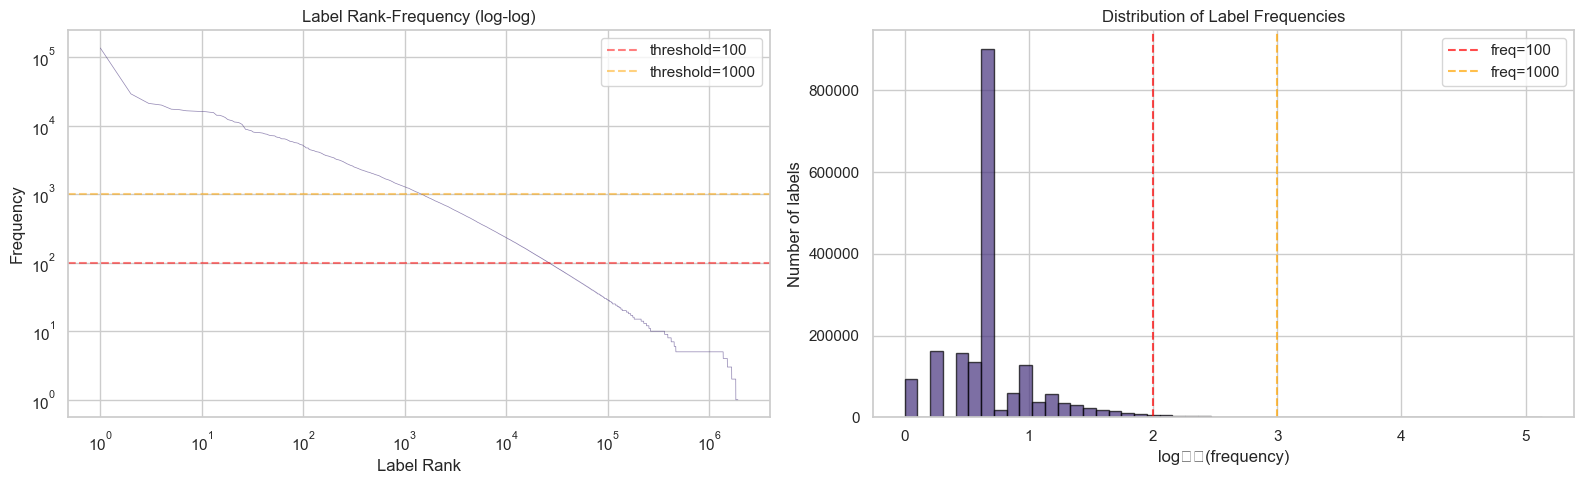


Labels appearing in >1.0% of texts (>18,508 occurrences): 4

These are overrepresented and candidates for trimming:
  historical_contextualization                        135,993 (7.35%)
  risk_mitigation_strategy                             29,134 (1.57%)
  chronological_progression                            21,121 (1.14%)
  historical_documentation                             19,973 (1.08%)


In [9]:
# ── Visualize label frequency distribution ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Log-log rank-frequency plot (Zipf's law)
ranks = np.arange(1, len(label_freq_series) + 1)
axes[0].loglog(ranks, label_freq_series.values, alpha=0.6, linewidth=0.5)
axes[0].set_xlabel("Label Rank")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Label Rank-Frequency (log-log)")
axes[0].axhline(y=100, color='r', linestyle='--', alpha=0.5, label='threshold=100')
axes[0].axhline(y=1000, color='orange', linestyle='--', alpha=0.5, label='threshold=1000')
axes[0].legend()

# Histogram of log frequencies
axes[1].hist(np.log10(label_freq_series.values), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel("log₁₀(frequency)")
axes[1].set_ylabel("Number of labels")
axes[1].set_title("Distribution of Label Frequencies")
axes[1].axvline(x=np.log10(100), color='r', linestyle='--', alpha=0.7, label='freq=100')
axes[1].axvline(x=np.log10(1000), color='orange', linestyle='--', alpha=0.7, label='freq=1000')
axes[1].legend()

plt.tight_layout()
plt.show()

# Overrepresentation: labels appearing in >1% of texts
threshold_pct = 1.0
threshold_count = int(len(df) * threshold_pct / 100)
overrep = label_freq_series[label_freq_series > threshold_count]
print(f"\nLabels appearing in >{threshold_pct}% of texts (>{threshold_count:,} occurrences): {len(overrep)}")
if len(overrep) > 0:
    print("\nThese are overrepresented and candidates for trimming:")
    for label, count in overrep.items():
        print(f"  {label:50s} {count:>8,} ({count/len(df)*100:.2f}%)")

In [10]:
# ── Positive-only label frequency (what the model sees as ground-truth) ──
pos_freq = pd.Series(all_pos_labels).sort_values(ascending=False)

print("TOP 30 POSITIVE LABELS (ground-truth for training)")
print("=" * 60)
for label, count in pos_freq.head(30).items():
    pct = count / len(df) * 100
    print(f"  {label:50s} {count:>8,} ({pct:.2f}%)")

# How many labels are overrepresented as positive?
overrep_pos = pos_freq[pos_freq > len(df) * 0.005]  # >0.5%
print(f"\nLabels >0.5% as positive: {len(overrep_pos)}")
print("These dominate training signal — model learns them too easily:")
for label, count in overrep_pos.items():
    print(f"  {label:50s} {count:>8,} ({count/len(df)*100:.2f}%)")

TOP 30 POSITIVE LABELS (ground-truth for training)
  historical_contextualization                         38,058 (2.06%)
  chronological_progression                             6,888 (0.37%)
  risk_mitigation_strategy                              6,624 (0.36%)
  contextual_framing                                    6,162 (0.33%)
  regional_contextualization                            6,162 (0.33%)
  historical_documentation                              6,141 (0.33%)
  personal_reflection                                   5,657 (0.31%)
  geographical_identification                           5,578 (0.30%)
  biographical_summary                                  5,514 (0.30%)
  geographical_contextualization                        4,645 (0.25%)
  historical_continuity                                 4,622 (0.25%)
  narrative_framing                                     4,585 (0.25%)
  historical_context                                    4,521 (0.24%)
  mild_positive_leaning                

## 4. Duplicate & Near-Duplicate Text Detection

- Exact duplicates via hash
- Near-duplicates via normalized text matching + TF-IDF cosine similarity on samples

In [11]:
# ── Exact duplicates ──
print("EXACT DUPLICATE DETECTION")
print("=" * 60)

# Normalize: lowercase, strip extra whitespace
df["text_norm"] = df["text"].str.lower().str.strip().str.replace(r'\s+', ' ', regex=True)
df["text_hash"] = df["text_norm"].apply(lambda t: hashlib.md5(t.encode()).hexdigest())

dup_counts = df["text_hash"].value_counts()
exact_dups = dup_counts[dup_counts > 1]

print(f"  Unique texts (by hash): {len(dup_counts):,}")
print(f"  Texts with exact duplicates: {exact_dups.sum() - len(exact_dups):,} extra copies")
print(f"  Duplicate groups: {len(exact_dups):,}")
print(f"  Max copies of same text: {exact_dups.max()}")
print()

# Show top duplicate groups
print("Top 10 most duplicated texts:")
for hash_val, count in exact_dups.head(10).items():
    text = df[df["text_hash"] == hash_val].iloc[0]["text"]
    print(f"  [{count}x] {text[:100]}...")
    print()

EXACT DUPLICATE DETECTION
  Unique texts (by hash): 1,850,810
  Texts with exact duplicates: 6 extra copies
  Duplicate groups: 6
  Max copies of same text: 2

Top 10 most duplicated texts:
  [2x] In no event shall the Provider be liable for consequential or incidental damages arising from the us...

  [2x] In no event shall the Provider be liable for consequential or incidental damages arising from the us...

  [2x] This Agreement shall be governed by and construed in accordance with the laws of the State of Delawa...

  [2x] This agreement is governed exclusively by the laws of the state of Delaware, without regard to its c...

  [2x] The provider shall not be liable for any indirect, incidental, or consequential damages arising from...

  [2x] In no event shall the provider be liable for any indirect, incidental, or consequential damages aris...



In [12]:
# ── Near-duplicates: TF-IDF + cosine similarity on random sample ──
# Full pairwise on 1.7M is infeasible, sample 50k texts
print("NEAR-DUPLICATE DETECTION (sampled)")
print("=" * 60)

SAMPLE_SIZE = min(50_000, len(df))
sample_df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

# TF-IDF vectorize
vectorizer = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), stop_words='english')
tfidf_matrix = vectorizer.fit_transform(sample_df["text_norm"])
print(f"  TF-IDF matrix: {tfidf_matrix.shape}")

# Find near-duplicates using batch cosine similarity
# Process in chunks to avoid memory issues
THRESHOLD = 0.85
near_dup_pairs = []

chunk_size = 5000
for i in range(0, SAMPLE_SIZE, chunk_size):
    chunk = tfidf_matrix[i:i+chunk_size]
    # Compare chunk against everything AFTER it (avoid double-counting)
    for j in range(i + chunk_size, SAMPLE_SIZE, chunk_size):
        other_chunk = tfidf_matrix[j:j+chunk_size]
        sim = cosine_similarity(chunk, other_chunk)
        pairs = np.argwhere(sim > THRESHOLD)
        for p in pairs:
            near_dup_pairs.append((i + p[0], j + p[1], sim[p[0], p[1]]))
    # Also check within-chunk
    if chunk.shape[0] > 1:
        sim_self = cosine_similarity(chunk)
        np.fill_diagonal(sim_self, 0)
        pairs = np.argwhere(sim_self > THRESHOLD)
        for p in pairs:
            if p[0] < p[1]:  # upper triangle only
                near_dup_pairs.append((i + p[0], i + p[1], sim_self[p[0], p[1]]))

print(f"  Near-duplicate pairs (cos>{THRESHOLD}): {len(near_dup_pairs):,}")
print(f"  Estimated in full dataset: ~{len(near_dup_pairs) * (len(df)/SAMPLE_SIZE)**2:.0f}")

if near_dup_pairs:
    print(f"\n  Sample near-duplicate pairs:")
    for idx1, idx2, score in sorted(near_dup_pairs, key=lambda x: -x[2])[:5]:
        print(f"    [{score:.3f}]")
        print(f"      A: {sample_df.loc[idx1, 'text'][:100]}...")
        print(f"      B: {sample_df.loc[idx2, 'text'][:100]}...")
        print()

NEAR-DUPLICATE DETECTION (sampled)
  TF-IDF matrix: (50000, 20000)
  Near-duplicate pairs (cos>0.85): 9
  Estimated in full dataset: ~12332

  Sample near-duplicate pairs:
    [0.938]
      A: You agree that we are not responsible for any problems that happen when you use this service....
      B: We are not responsible for any problems that happen while you use our service....

    [0.918]
      A: It sits somewhere to the southwest, near both Venice and the city of Padua....
      B: It sits southwest of both Venice and Padua....

    [0.896]
      A: First, plug the main power cord securely into the designated socket on the rear panel of the unit....
      B: 1. Plug the main power cable securely into the designated port on the rear panel of the unit....

    [0.894]
      A: 1. Locate the main power switch on the device panel and flip it to the 'On' position....
      B: 1. Locate the main power switch on the side panel. 2. Flip the switch to the 'On' position to begin ...

    [0.

## 5. Label Contradiction Detection

Find cases where very similar texts have contradicting labels (same label is positive in one and negative in another nearly identical text).

In [13]:
# ── Contradiction detection ──
# A contradiction: two similar texts where label X is positive in one, negative in another
# Use the near-duplicate pairs we found + check their label overlap

print("LABEL CONTRADICTIONS IN NEAR-DUPLICATE PAIRS")
print("=" * 60)

contradictions = []
for idx1, idx2, sim_score in near_dup_pairs:
    row1 = sample_df.iloc[idx1]
    row2 = sample_df.iloc[idx2]
    
    pos1 = set(row1["labels"])
    neg1 = set(row1["not_labels"])
    pos2 = set(row2["labels"])
    neg2 = set(row2["not_labels"])
    
    # Labels that are positive in one but negative in the other
    contra_1to2 = pos1 & neg2
    contra_2to1 = pos2 & neg1
    all_contra = contra_1to2 | contra_2to1
    
    if all_contra:
        contradictions.append({
            "idx1": idx1, "idx2": idx2,
            "similarity": sim_score,
            "contradicted_labels": all_contra,
            "n_contradictions": len(all_contra),
            "text1": row1["text"][:80],
            "text2": row2["text"][:80],
        })

print(f"  Near-dup pairs with contradictions: {len(contradictions)}/{len(near_dup_pairs)}")

if contradictions:
    for c in sorted(contradictions, key=lambda x: -x["n_contradictions"])[:5]:
        print(f"\n  Similarity: {c['similarity']:.3f} | Contradicted labels: {c['n_contradictions']}")
        print(f"    Text A: {c['text1']}...")
        print(f"    Text B: {c['text2']}...")
        print(f"    Conflicting: {list(c['contradicted_labels'])[:5]}")
else:
    print("  ✓ No label contradictions found in near-duplicate pairs!")

LABEL CONTRADICTIONS IN NEAR-DUPLICATE PAIRS
  Near-dup pairs with contradictions: 0/9
  ✓ No label contradictions found in near-duplicate pairs!


LABEL ROLE DISTRIBUTION
  Labels only positive: 115,559
  Labels only negative: 182,087
  Labels in BOTH roles: 1,617,118

  Pos/(Pos+Neg) ratio stats for dual-role labels:
    mean: 0.319
    median: 0.286
    std: 0.137

  Almost always negative (ratio<0.1): 3,808
  Almost always positive (ratio>0.9): 22
  Balanced (0.3-0.7): 743,056


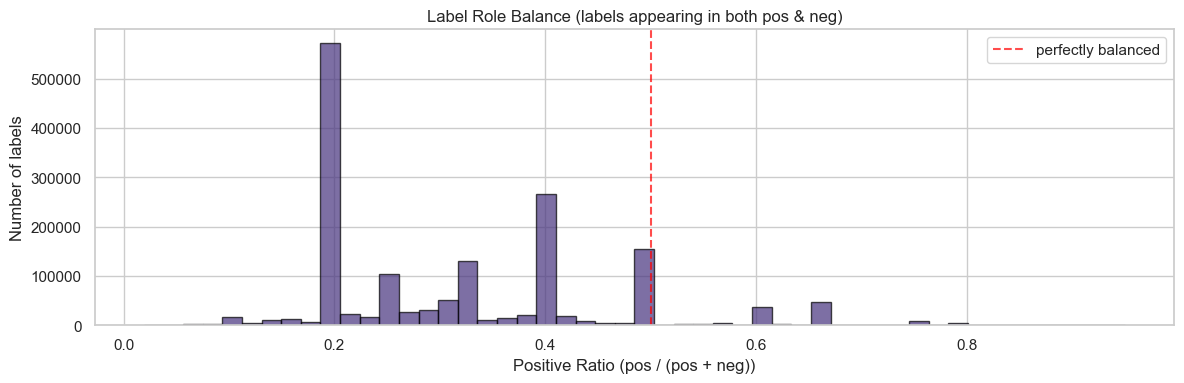

In [14]:
# ── Cross-role check: labels used as both positive AND negative (expected by design) ──
# But check the RATIO — a useful label should be both pos & neg, not just always neg

pos_set = set(all_pos_labels.keys())
neg_set = set(all_neg_labels.keys())
both_roles = pos_set & neg_set

print("LABEL ROLE DISTRIBUTION")
print("=" * 60)
print(f"  Labels only positive: {len(pos_set - neg_set):,}")
print(f"  Labels only negative: {len(neg_set - pos_set):,}")
print(f"  Labels in BOTH roles: {len(both_roles):,}")
print()

# For labels in both roles, what's the pos/neg ratio?
ratios = {}
for label in both_roles:
    pos_c = all_pos_labels[label]
    neg_c = all_neg_labels[label]
    total = pos_c + neg_c
    ratios[label] = pos_c / total

ratio_series = pd.Series(ratios)
print(f"  Pos/(Pos+Neg) ratio stats for dual-role labels:")
print(f"    mean: {ratio_series.mean():.3f}")
print(f"    median: {ratio_series.median():.3f}")
print(f"    std: {ratio_series.std():.3f}")

# Labels that are almost always negative (ratio < 0.1) — they might as well be removed
always_neg = ratio_series[ratio_series < 0.1]
always_pos = ratio_series[ratio_series > 0.9]
print(f"\n  Almost always negative (ratio<0.1): {len(always_neg):,}")
print(f"  Almost always positive (ratio>0.9): {len(always_pos):,}")
print(f"  Balanced (0.3-0.7): {((ratio_series > 0.3) & (ratio_series < 0.7)).sum():,}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(ratio_series.values, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel("Positive Ratio (pos / (pos + neg))")
ax.set_ylabel("Number of labels")
ax.set_title("Label Role Balance (labels appearing in both pos & neg)")
ax.axvline(x=0.5, color='r', linestyle='--', alpha=0.7, label='perfectly balanced')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Label Quality & Usefulness Scoring

Evaluate label quality:
- **Too generic**: labels that are so broad they apply to many unrelated texts (e.g., "information_sharing")
- **Too specific**: labels that only appear once and won't help generalization
- **Malformed**: labels with formatting issues (not snake_case, too long/short)
- **Shallow/surface**: labels about topic rather than meaning/intent

In [15]:
# ── Label format quality ──
all_label_list = list(all_label_freq.keys())

print("LABEL FORMAT QUALITY")
print("=" * 60)

# Snake_case check
non_snake = [l for l in all_label_list if not re.match(r'^[a-z][a-z0-9_]*$', l)]
print(f"  Non-snake_case labels: {len(non_snake):,} ({len(non_snake)/len(all_label_list)*100:.3f}%)")
if non_snake[:10]:
    print(f"    Examples: {non_snake[:10]}")

# Word count
word_counts = pd.Series([len(l.split('_')) for l in all_label_list])
print(f"\n  Word count distribution:")
print(f"    1 word:   {(word_counts == 1).sum():>8,} ({(word_counts == 1).sum()/len(all_label_list)*100:.2f}%)")
print(f"    2 words:  {(word_counts == 2).sum():>8,} ({(word_counts == 2).sum()/len(all_label_list)*100:.2f}%)")
print(f"    3 words:  {(word_counts == 3).sum():>8,} ({(word_counts == 3).sum()/len(all_label_list)*100:.2f}%)")
print(f"    4 words:  {(word_counts == 4).sum():>8,} ({(word_counts == 4).sum()/len(all_label_list)*100:.2f}%)")
print(f"    5 words:  {(word_counts == 5).sum():>8,} ({(word_counts == 5).sum()/len(all_label_list)*100:.2f}%)")
print(f"    6+ words: {(word_counts >= 6).sum():>8,} ({(word_counts >= 6).sum()/len(all_label_list)*100:.2f}%)")

# Labels that are too long (>60 chars)
long_labels = [l for l in all_label_list if len(l) > 60]
print(f"\n  Labels >60 chars: {len(long_labels):,}")
if long_labels[:5]:
    for l in long_labels[:5]:
        print(f"    {l} ({len(l)} chars)")

# Labels with digits (often low quality like "step_1")
digit_labels = [l for l in all_label_list if re.search(r'\d', l)]
print(f"\n  Labels containing digits: {len(digit_labels):,}")
if digit_labels[:10]:
    print(f"    Examples: {digit_labels[:10]}")

LABEL FORMAT QUALITY
  Non-snake_case labels: 36,040 (1.882%)
    Examples: ['cross-regional_artistic_mobility', 'disciplinary_cross-pollination', 'Methodological_Constraint', 'Operational_Precondition', 'Procedural_Instruction', 'System_Component_Identification', 'Contextual_Setting', 'Informational_Verification', 'Narrative_Reference', 'Source_Attribution']

  Word count distribution:
    1 word:     25,447 (1.33%)
    2 words:   223,055 (11.65%)
    3 words:  1,168,995 (61.05%)
    4 words:   437,302 (22.84%)
    5 words:    53,772 (2.81%)
    6+ words:    6,193 (0.32%)

  Labels >60 chars: 289
    one of four All India Financial Institutions regulated by RBI (61 chars)
    Catholic literary humanism as counter-Enlightenment tradition (61 chars)
    missionary spirituality applied to secular educational contexts (63 chars)
    mentorship of hundreds of graduate students and PhD researchers (63 chars)
    comprehensive documentation spanning dictionaries, epics, and grammar (69 chars

In [16]:
# ── Label semantic quality: shallow (topic) vs deep (intent/meaning) ──

# Deep indicators: words suggesting rhetorical/epistemic/affective meaning
deep_indicators = {
    "assertion", "claim", "endorsement", "critique", "speculation",
    "recommendation", "observation", "framing", "evaluation", "stance",
    "rhetorical", "epistemic", "argument", "rebuttal", "concession",
    "hedged", "certainty", "approval", "disapproval", "reservation",
    "tone", "register", "emphasis", "sentiment", "persuasion",
    "advocacy", "skepticism", "optimism", "pessimism", "neutral",
    "positive", "negative", "emotional", "analytical", "narrative",
    "subjective", "objective", "opinion", "sarcasm", "irony",
    "urgency", "warning", "caution", "encouragement", "dismissal",
}

# Shallow indicators: surface topic words, proper nouns, dates
shallow_indicators = {
    "description", "information", "sharing", "mention", "reference",
    "about", "related", "context", "general", "basic", "simple",
    "noting", "stating", "indicating", "providing", "reporting",
}

label_quality = pd.DataFrame({
    "label": all_label_list,
    "freq": [all_label_freq[l] for l in all_label_list],
})
label_quality["n_words"] = label_quality["label"].str.split("_").str.len()
label_quality["has_deep_word"] = label_quality["label"].apply(
    lambda l: any(w in l.split("_") for w in deep_indicators)
)
label_quality["has_shallow_word"] = label_quality["label"].apply(
    lambda l: any(w in l.split("_") for w in shallow_indicators)
)
label_quality["is_snake_case"] = label_quality["label"].str.match(r'^[a-z][a-z0-9_]*$')
label_quality["has_digit"] = label_quality["label"].str.contains(r'\d', regex=True)
label_quality["char_len"] = label_quality["label"].str.len()

print("LABEL SEMANTIC QUALITY")
print("=" * 60)
print(f"  Total labels: {len(label_quality):,}")
print(f"  Deep (rhetorical/epistemic): {label_quality['has_deep_word'].sum():,} ({label_quality['has_deep_word'].mean()*100:.1f}%)")
print(f"  Shallow (surface/topic): {label_quality['has_shallow_word'].sum():,} ({label_quality['has_shallow_word'].mean()*100:.1f}%)")
print(f"  Neither: {(~label_quality['has_deep_word'] & ~label_quality['has_shallow_word']).sum():,}")

# Quality score: penalize too frequent, not snake_case, single word, has digits, too long
label_quality["quality_score"] = 1.0
label_quality.loc[~label_quality["is_snake_case"], "quality_score"] -= 0.3
label_quality.loc[label_quality["has_digit"], "quality_score"] -= 0.2
label_quality.loc[label_quality["n_words"] == 1, "quality_score"] -= 0.3
label_quality.loc[label_quality["n_words"] >= 6, "quality_score"] -= 0.2
label_quality.loc[label_quality["char_len"] > 50, "quality_score"] -= 0.2
label_quality.loc[label_quality["freq"] > 10000, "quality_score"] -= 0.3

print(f"\n  Quality score distribution:")
print(label_quality["quality_score"].describe())

# Worst quality labels
print(f"\n  LOWEST QUALITY LABELS (score < 0.5):")
worst = label_quality[label_quality["quality_score"] < 0.5].sort_values("quality_score")
print(f"  Count: {len(worst):,}")
for _, row in worst.head(15).iterrows():
    print(f"    [{row['quality_score']:.1f}] {row['label'][:60]:60s} (freq={row['freq']:,})")

LABEL SEMANTIC QUALITY
  Total labels: 1,914,764
  Deep (rhetorical/epistemic): 226,730 (11.8%)
  Shallow (surface/topic): 91,763 (4.8%)
  Neither: 1,601,347

  Quality score distribution:
count    1.914764e+06
mean     9.893594e-01
std      7.535016e-02
min     -5.551115e-17
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: quality_score, dtype: float64

  LOWEST QUALITY LABELS (score < 0.5):
  Count: 24,825
    [-0.0] linear adjustment of 757 primary levelling sections          (freq=1)
    [-0.0] Provincial War Finance Committee leadership 1942-1945        (freq=2)
    [-0.0] Coleman Medal as league's leading goalkicker in 2013         (freq=1)
    [-0.0] Achilles tendon rupture during a 2011 finals match against G (freq=2)
    [-0.0] melanoma recurrence with lung metastases diagnosed in 2016   (freq=1)
    [-0.0] projectile range maximized by 45 degree launch angle         (freq=1)
    [-0.0] identical reading of 5 to 3 on complementary s

## 7. Text Cleaning Deep-Dive: Structural Issues

Detect texts that start with numbering, contain inline comments from the model, have system-prompt leakage, or structural anomalies.

In [17]:
# ── Deeper text cleaning: structural patterns ──
print("TEXT STRUCTURAL ISSUES")
print("=" * 60)

# 1. Texts that start with a number (e.g., "1. ", "5. ") — list items, not natural text
starts_numbered = df["text"].str.match(r'^\s*\d+[.)]\s', na=False)
print(f"  Starts with numbered list: {starts_numbered.sum():,} ({starts_numbered.sum()/len(df)*100:.2f}%)")

# 2. Contains JSON structure
has_json = df["text"].str.contains(r'[\{"\[]\s*"[a-z_]+"', regex=True, na=False)
print(f"  Contains JSON-like structure: {has_json.sum():,} ({has_json.sum()/len(df)*100:.3f}%)")

# 3. System prompt leakage / instruction following artifacts
prompt_leak_patterns = [
    r'\btext \d+ of \d+\b',
    r'\b(?:bundle|batch)\s*\d+',
    r'</?text>',
    r'</?output>',
    r'\bgenre:\s',
    r'\blabels?:\s*\[',
]
prompt_leak = df["text"].str.contains('|'.join(prompt_leak_patterns), case=False, regex=True, na=False)
print(f"  Prompt/system leakage: {prompt_leak.sum():,} ({prompt_leak.sum()/len(df)*100:.3f}%)")

# 4. Starts with quotation that's never closed
unclosed_quote = df["text"].str.match(r'^"[^"]{20,}$', na=False)  # starts with " but no closing "
print(f"  Unclosed leading quote: {unclosed_quote.sum():,}")

# 5. Very long single "word" (no spaces) — garbled output
no_spaces = df["text"].apply(lambda t: max(len(w) for w in t.split()) if t.strip() else 0)
garbled = no_spaces > 80
print(f"  Contains >80-char 'word' (garbled): {garbled.sum():,}")

# 6. All caps or mostly caps
mostly_caps = df["text"].apply(lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1) > 0.7)
print(f"  Mostly CAPS (>70%): {mostly_caps.sum():,}")

# Show examples of each
print("\n" + "─" * 60)
print("EXAMPLES: Prompt/system leakage")
if prompt_leak.sum() > 0:
    for _, row in df[prompt_leak].head(5).iterrows():
        print(f"  → {row['text'][:120]}")
        print()

print("─" * 60)
print("EXAMPLES: Contains >80-char word (garbled)")
if garbled.sum() > 0:
    for _, row in df[garbled].head(5).iterrows():
        print(f"  → {row['text'][:150]}")
        print()

TEXT STRUCTURAL ISSUES
  Starts with numbered list: 18,093 (0.98%)
  Contains JSON-like structure: 3 (0.000%)
  Prompt/system leakage: 13 (0.001%)
  Unclosed leading quote: 0
  Contains >80-char 'word' (garbled): 12
  Mostly CAPS (>70%): 224

────────────────────────────────────────────────────────────
EXAMPLES: Prompt/system leakage
  → The researcher observes how the text establishes institutional authority through its deliberate minimalism, presenting f

  → NOTICE: Service status changed. Batch 556-558 now active. All prior instances marked deprecated. Recommend immediate rot

  → ALERT: Deployment sequence error. Batch 563-570 skipped prerequisite phase 3. System pending upgrade path NG-18 integrat

  → Block casting defect detected. Scrap unit batch 77. Halt assembly.

  → The modern iteration of the designation, exemplified by the 2018 commissioning of the first Batch 2 ship, signals a dram

────────────────────────────────────────────────────────────
EXAMPLES: Contains >80-char

In [18]:
# ── Model comparison: quality differences between Gemma4E4B and Qwen36-27B ──
print("MODEL COMPARISON")
print("=" * 60)

for model_name in df["model"].unique():
    sub = df[df["model"] == model_name]
    print(f"\n  {model_name} ({len(sub):,} texts):")
    print(f"    Text length (words): mean={sub['text_len_words'].mean():.0f}, median={sub['text_len_words'].median():.0f}")
    print(f"    Sentences: mean={sub['n_sentences'].mean():.1f}")
    print(f"    Pos labels: mean={sub['n_pos'].mean():.1f}")
    print(f"    Neg labels: mean={sub['n_neg'].mean():.1f}")
    
    # Flags for this model
    sub_flags = flags.loc[sub.index]
    flagged = sub_flags.any(axis=1).sum()
    print(f"    Flagged (any): {flagged:,} ({flagged/len(sub)*100:.2f}%)")
    
    # Specific: meta_comment, markdown, code
    print(f"    meta_comment: {flags.loc[sub.index, 'meta_comment'].sum():,}")
    print(f"    has_markdown: {flags.loc[sub.index, 'has_markdown'].sum():,}")
    print(f"    no_ending_punct: {flags.loc[sub.index, 'no_ending_punct'].sum():,}")
    print(f"    starts_with_number: {flags.loc[sub.index, 'starts_with_number_list'].sum():,}")

MODEL COMPARISON

  Gemma4E4B (1,731,913 texts):
    Text length (words): mean=43, median=32
    Sentences: mean=2.5
    Pos labels: mean=3.8
    Neg labels: mean=9.4
    Flagged (any): 65,941 (3.81%)
    meta_comment: 196
    has_markdown: 3,117
    no_ending_punct: 12,711
    starts_with_number: 17,408

  Qwen36-27B (118,903 texts):
    Text length (words): mean=51, median=47
    Sentences: mean=2.8
    Pos labels: mean=3.5
    Neg labels: mean=3.7
    Flagged (any): 9,904 (8.33%)
    meta_comment: 37
    has_markdown: 420
    no_ending_punct: 6,366
    starts_with_number: 685


⚠ NEGATIVE LABEL COUNT BY MODEL



  Gemma4E4B:
    Neg labels: min=1, max=35, mean=9.4, median=11
    In [8,15]: 1,458,841 (84.2%)
    Under 8: 273,054 (15.8%)

  Qwen36-27B:
    Neg labels: min=1, max=14, mean=3.7, median=3
    In [8,15]: 1,271 (1.1%)
    Under 8: 117,632 (98.9%)


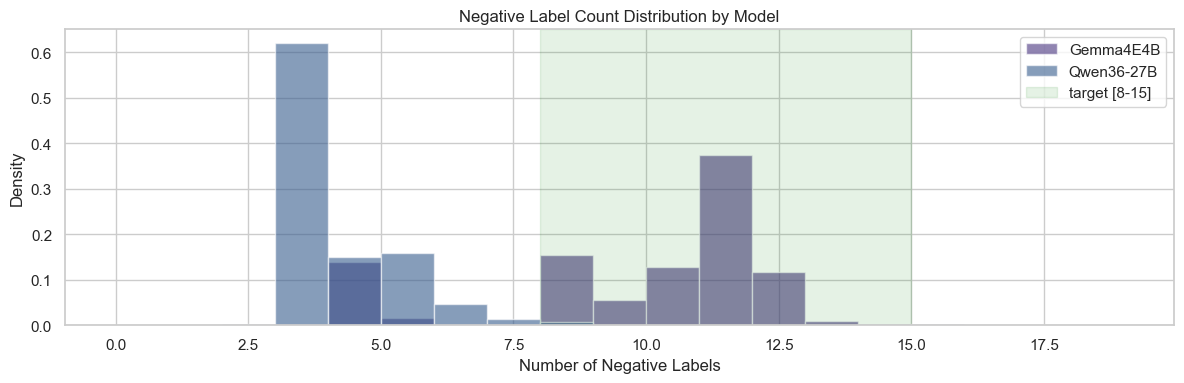

In [19]:
# ── Critical: Qwen has very few negative labels (mean 3.7 vs expected 8-15) ──
print("⚠ NEGATIVE LABEL COUNT BY MODEL")
print("=" * 60)

for model_name in df["model"].unique():
    sub = df[df["model"] == model_name]
    neg = sub["n_neg"]
    print(f"\n  {model_name}:")
    print(f"    Neg labels: min={neg.min()}, max={neg.max()}, mean={neg.mean():.1f}, median={neg.median():.0f}")
    in_range = ((neg >= 8) & (neg <= 15)).sum()
    print(f"    In [8,15]: {in_range:,} ({in_range/len(sub)*100:.1f}%)")
    under = (neg < 8).sum()
    print(f"    Under 8: {under:,} ({under/len(sub)*100:.1f}%)")

# Histogram of neg label counts by model
fig, ax = plt.subplots(figsize=(12, 4))
for model_name in df["model"].unique():
    sub = df[df["model"] == model_name]
    ax.hist(sub["n_neg"], bins=range(0, 20), alpha=0.6, label=model_name, density=True)
ax.set_xlabel("Number of Negative Labels")
ax.set_ylabel("Density")
ax.set_title("Negative Label Count Distribution by Model")
ax.axvspan(8, 15, alpha=0.1, color='green', label='target [8-15]')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Final Cleaning Recommendations & Summary

Actionable filters for the data cleaning pipeline.

In [20]:
# ══════════════════════════════════════════════════════════════
# COMPREHENSIVE CLEANING PIPELINE
# ══════════════════════════════════════════════════════════════

print("CLEANING PIPELINE — APPLYING ALL FILTERS")
print("=" * 70)
print(f"Starting dataset: {len(df):,} examples\n")

# Track removal reasons
removal_reasons = {}

# ── Filter 1: Empty/too short texts (<5 words) ──
mask_tiny = df["text_len_words"] < 5
removal_reasons["Too short (<5 words)"] = mask_tiny.sum()

# ── Filter 2: Meta-comments ──
mask_meta = flags["meta_comment"]
removal_reasons["Meta-comments"] = mask_meta.sum()

# ── Filter 3: Garbled text (>80 char words) ──
mask_garbled = garbled
removal_reasons["Garbled text"] = mask_garbled.sum()

# ── Filter 4: Mostly CAPS ──
mask_caps = mostly_caps
removal_reasons["Mostly CAPS"] = mask_caps.sum()

# ── Filter 5: Exact duplicates (keep first) ──
mask_dup = df.duplicated(subset="text_hash", keep="first")
removal_reasons["Exact duplicates"] = mask_dup.sum()

# ── Filter 6: Prompt leakage ──
mask_leak = prompt_leak
removal_reasons["Prompt leakage"] = mask_leak.sum()

# ── Filter 7: Labels too few overall (pos + neg < 5) ──
mask_few_labels = df["n_total"] < 5
removal_reasons["Too few labels (<5 total)"] = mask_few_labels.sum()

# ── Filter 8: Starts with code comment (// or /* or #!) ──
mask_code_comment = df["text"].str.match(r'^\s*(?://|/\*|#!)', na=False)
removal_reasons["Code comments (// /*)"] = mask_code_comment.sum()

# Combine all removal masks
mask_remove = (mask_tiny | mask_meta | mask_garbled | mask_caps | mask_dup 
               | mask_leak | mask_few_labels | mask_code_comment)

print("Removal reasons (with overlap):")
for reason, count in sorted(removal_reasons.items(), key=lambda x: -x[1]):
    print(f"  {reason:35s}: {count:>8,} ({count/len(df)*100:.2f}%)")

print(f"\n  {'TOTAL REMOVED (deduplicated)':35s}: {mask_remove.sum():>8,} ({mask_remove.sum()/len(df)*100:.2f}%)")
print(f"  {'REMAINING (clean)':35s}: {(~mask_remove).sum():>8,} ({(~mask_remove).sum()/len(df)*100:.2f}%)")

CLEANING PIPELINE — APPLYING ALL FILTERS
Starting dataset: 1,850,816 examples

Removal reasons (with overlap):
  Code comments (// /*)              :    9,071 (0.49%)
  Too few labels (<5 total)          :    3,501 (0.19%)
  Too short (<5 words)               :      275 (0.01%)
  Meta-comments                      :      233 (0.01%)
  Mostly CAPS                        :      224 (0.01%)
  Prompt leakage                     :       13 (0.00%)
  Garbled text                       :       12 (0.00%)
  Exact duplicates                   :        6 (0.00%)

  TOTAL REMOVED (deduplicated)       :   13,252 (0.72%)
  REMAINING (clean)                  : 1,837,564 (99.28%)


In [21]:
# ── Label-level cleaning: filter out bad labels from remaining texts ──
print("LABEL-LEVEL CLEANING")
print("=" * 70)

df_clean = df[~mask_remove].copy()

# Labels to remove entirely from label lists:
bad_labels = set()

# 1. Not snake_case
non_snake_labels = set(l for l in all_label_list if not re.match(r'^[a-z][a-z0-9_]*$', l))
bad_labels.update(non_snake_labels)
print(f"  Non-snake_case labels to remove: {len(non_snake_labels):,}")

# 2. Single word (too vague)
single_word = set(l for l in all_label_list if '_' not in l)
bad_labels.update(single_word)
print(f"  Single-word labels: {len(single_word):,}")

# 3. Contains digits (dates, step numbers — too specific)
digit_labels_set = set(l for l in all_label_list if re.search(r'\d', l))
bad_labels.update(digit_labels_set)
print(f"  Contains digits: {len(digit_labels_set):,}")

print(f"\n  TOTAL BAD LABELS (union): {len(bad_labels):,}")
print(f"  These appear in label lists {sum(all_label_freq[l] for l in bad_labels if l in all_label_freq):,} total times")

# Impact: how many texts have at least one bad label?
has_bad_pos = df_clean["labels"].apply(lambda labels: bool(set(labels) & bad_labels))
has_bad_neg = df_clean["not_labels"].apply(lambda labels: bool(set(labels) & bad_labels))
print(f"\n  Texts with ≥1 bad positive label: {has_bad_pos.sum():,} ({has_bad_pos.sum()/len(df_clean)*100:.1f}%)")
print(f"  Texts with ≥1 bad negative label: {has_bad_neg.sum():,} ({has_bad_neg.sum()/len(df_clean)*100:.1f}%)")
print(f"  → These texts are NOT removed, just their label lists get filtered")

LABEL-LEVEL CLEANING
  Non-snake_case labels to remove: 36,040
  Single-word labels: 25,447
  Contains digits: 1,579

  TOTAL BAD LABELS (union): 37,068
  These appear in label lists 110,178 total times

  Texts with ≥1 bad positive label: 16,487 (0.9%)
  Texts with ≥1 bad negative label: 26,832 (1.5%)
  → These texts are NOT removed, just their label lists get filtered


## 9. Label Pruning — Overrepresented Labels

Use `max(pos_count, neg_count)` as effective frequency. Prune labels appearing >1000× the median by randomly removing them from texts that already have enough labels.

In [22]:
# ── Label frequency using max(pos_count, neg_count) ──
# This gives the "effective" frequency — how often a label dominates the signal

label_effective_freq = {}
all_labels_union = set(all_pos_labels.keys()) | set(all_neg_labels.keys())
for label in all_labels_union:
    pos_c = all_pos_labels.get(label, 0)
    neg_c = all_neg_labels.get(label, 0)
    label_effective_freq[label] = max(pos_c, neg_c)

eff_freq_series = pd.Series(label_effective_freq).sort_values(ascending=False)

# Stats
median_freq = eff_freq_series.median()
mean_freq = eff_freq_series.mean()
print("LABEL EFFECTIVE FREQUENCY — max(pos_count, neg_count)")
print("=" * 70)
print(f"  Total unique labels: {len(eff_freq_series):,}")
print(f"  Median frequency: {median_freq:.0f}")
print(f"  Mean frequency: {mean_freq:.1f}")
print(f"  Max frequency: {eff_freq_series.max():,}")
print()

# Threshold: 1000x the median
prune_threshold = int(median_freq * 1000)
print(f"  Prune threshold (1000 × median = {median_freq:.0f} × 1000): {prune_threshold:,}")

# Labels exceeding threshold
overrep_labels = eff_freq_series[eff_freq_series > prune_threshold]
print(f"  Labels above threshold: {len(overrep_labels):,}")
print()

print("  OVERREPRESENTED LABELS TO PRUNE:")
for label, freq in overrep_labels.head(30).items():
    ratio = freq / median_freq
    print(f"    {label:50s} {freq:>8,} ({ratio:.0f}× median)")

LABEL EFFECTIVE FREQUENCY — max(pos_count, neg_count)
  Total unique labels: 1,914,764
  Median frequency: 4
  Mean frequency: 8.9
  Max frequency: 97,935

  Prune threshold (1000 × median = 4 × 1000): 4,000
  Labels above threshold: 77

  OVERREPRESENTED LABELS TO PRUNE:
    historical_contextualization                         97,935 (24484× median)
    risk_mitigation_strategy                             22,510 (5628× median)
    chronological_progression                            14,233 (3558× median)
    historical_documentation                             13,832 (3458× median)
    narrative_framing                                    12,816 (3204× median)
    geographical_identification                          11,530 (2882× median)
    historical_context                                   11,479 (2870× median)
    chronological_sequencing                             11,350 (2838× median)
    biographical_summary                                 10,981 (2745× median)
    resource_al

In [23]:
# ── Prune overrepresented labels randomly from texts that have enough labels ──
# Strategy: For each overrepresented label, reduce its frequency to the threshold
# by randomly removing it from texts where the text still has enough labels after removal.
# "Enough" = at least 1 positive label and at least 1 negative label remaining.

import random
random.seed(42)

target_freq = prune_threshold  # 1000 × median
overrep_set = set(overrep_labels.index)

print("LABEL PRUNING — Reducing overrepresented labels")
print("=" * 70)
print(f"  Target max frequency per label: {target_freq:,}")
print(f"  Labels to prune: {len(overrep_set):,}")
print()

# Work on the clean subset
df_pruned = df_clean.copy()

# Remove bad labels first (non-snake_case, single word, digits)
df_pruned["labels"] = df_pruned["labels"].apply(lambda ls: [l for l in ls if l not in bad_labels])
df_pruned["not_labels"] = df_pruned["not_labels"].apply(lambda ls: [l for l in ls if l not in bad_labels])

# Now prune overrepresented labels
# For each overrep label, find all texts containing it and randomly select which ones to remove it from
prune_stats = {}

for label in overrep_labels.index:
    # Find texts with this label (in pos or neg)
    in_pos = df_pruned["labels"].apply(lambda ls: label in ls)
    in_neg = df_pruned["not_labels"].apply(lambda ls: label in ls)
    
    pos_count = in_pos.sum()
    neg_count = in_neg.sum()
    current_max = max(pos_count, neg_count)
    
    if current_max <= target_freq:
        continue
    
    excess = current_max - target_freq
    
    # Choose which role (pos or neg) has the higher count — prune from that
    if pos_count >= neg_count:
        # Prune from positive labels
        candidate_idx = df_pruned.index[in_pos]
        # Only prune from texts that have >1 positive label (keep at least 1)
        can_prune = df_pruned.loc[candidate_idx, "labels"].apply(lambda ls: len(ls) > 1)
        prunable_idx = candidate_idx[can_prune]
    else:
        # Prune from negative labels
        candidate_idx = df_pruned.index[in_neg]
        # Only prune from texts that have >1 negative label (keep at least 1)
        can_prune = df_pruned.loc[candidate_idx, "not_labels"].apply(lambda ls: len(ls) > 1)
        prunable_idx = candidate_idx[can_prune]
    
    # Randomly select indices to prune from
    n_to_prune = min(excess, len(prunable_idx))
    if n_to_prune == 0:
        continue
    
    prune_from = set(random.sample(list(prunable_idx), n_to_prune))
    
    # Apply pruning
    if pos_count >= neg_count:
        df_pruned.loc[list(prune_from), "labels"] = df_pruned.loc[list(prune_from), "labels"].apply(
            lambda ls: [l for l in ls if l != label]
        )
    else:
        df_pruned.loc[list(prune_from), "not_labels"] = df_pruned.loc[list(prune_from), "not_labels"].apply(
            lambda ls: [l for l in ls if l != label]
        )
    
    prune_stats[label] = {"original": current_max, "pruned": n_to_prune, "remaining": current_max - n_to_prune}

print(f"  Labels actually pruned: {len(prune_stats):,}")
print(f"  Total label removals: {sum(s['pruned'] for s in prune_stats.values()):,}")
print()
print("  TOP 10 MOST PRUNED:")
for label, stats in sorted(prune_stats.items(), key=lambda x: -x[1]["pruned"])[:10]:
    print(f"    {label:50s} {stats['original']:>8,} → {stats['remaining']:>8,} (removed {stats['pruned']:,})")

LABEL PRUNING — Reducing overrepresented labels
  Target max frequency per label: 4,000
  Labels to prune: 77

  Labels actually pruned: 75
  Total label removals: 305,858

  TOP 10 MOST PRUNED:
    historical_contextualization                         97,555 →    4,000 (removed 93,555)
    risk_mitigation_strategy                             22,469 →    4,000 (removed 18,469)
    chronological_progression                            14,186 →    4,000 (removed 10,186)
    historical_documentation                             13,820 →    4,000 (removed 9,820)
    narrative_framing                                    12,811 →    4,000 (removed 8,811)
    geographical_identification                          11,512 →    4,000 (removed 7,512)
    historical_context                                   11,433 →    4,000 (removed 7,433)
    chronological_sequencing                             11,288 →    4,000 (removed 7,288)
    resource_allocation_justification                    10,951 →    4,000

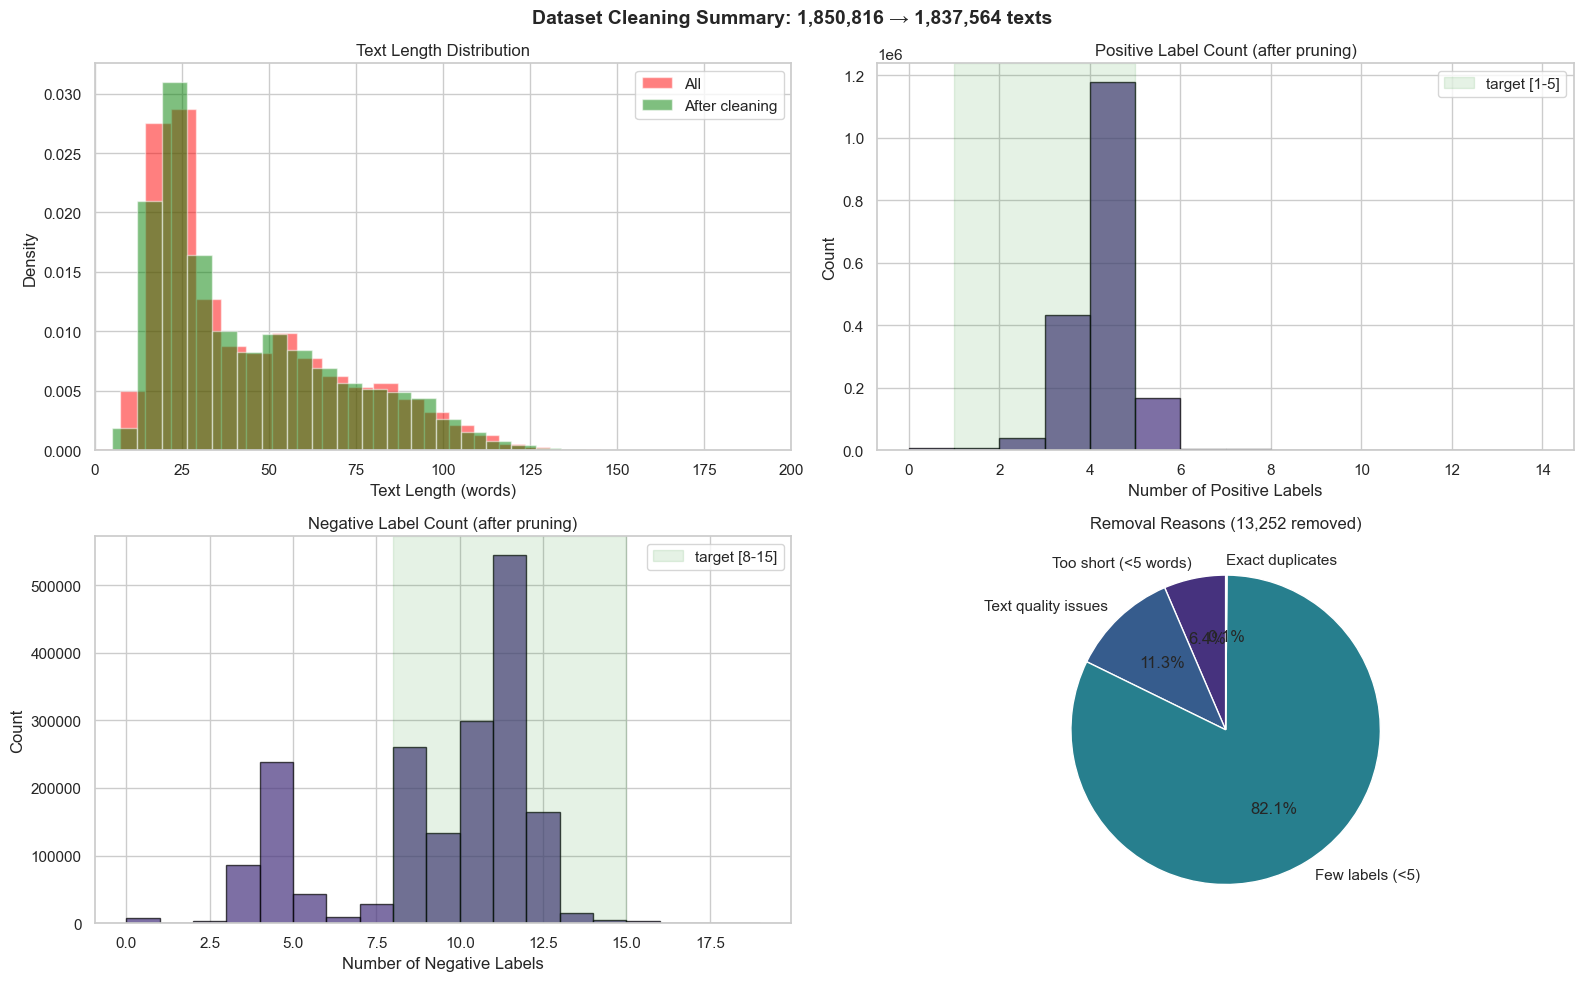


══════════════════════════════════════════════════════════════════════
FINAL DATASET STATISTICS
══════════════════════════════════════════════════════════════════════
  Original:        1,850,816 texts
  Removed:            13,252 texts (0.72%)
  Remaining:       1,837,564 texts
  Bad labels:         37,068 labels stripped from label lists
  Overrep labels:         75 labels pruned (>4,000 effective freq)
  Total label removals:    305,858

  Key actions:
    • 13,252 texts removed (too short, meta-comments, garbled, caps, prompt leak, dupes)
    • 37,068 malformed labels stripped (non-snake_case, single word, digits)
    • 75 overrepresented labels pruned to ≤4,000 occurrences each
    • Qwen36-27B data kept (low neg labels is NOT a removal reason)
    • Near-zero exact duplicates (6 pairs) — minimal concern


In [24]:
# ══════════════════════════════════════════════════════════════
# FINAL SUMMARY DASHBOARD
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Text length distribution (before/after)
ax = axes[0, 0]
ax.hist(df["text_len_words"], bins=50, alpha=0.5, label="All", density=True, color="red")
ax.hist(df_clean["text_len_words"], bins=50, alpha=0.5, label="After cleaning", density=True, color="green")
ax.set_xlabel("Text Length (words)")
ax.set_ylabel("Density")
ax.set_title("Text Length Distribution")
ax.legend()
ax.set_xlim(0, 200)

# 2. Positive label count (after pruning)
ax = axes[0, 1]
pos_counts_pruned = df_pruned["labels"].apply(len)
ax.hist(pos_counts_pruned, bins=range(0, 15), alpha=0.7, edgecolor='black')
ax.set_xlabel("Number of Positive Labels")
ax.set_ylabel("Count")
ax.set_title("Positive Label Count (after pruning)")
ax.axvspan(1, 5, alpha=0.1, color='green', label='target [1-5]')
ax.legend()

# 3. Negative label count (after pruning)
ax = axes[1, 0]
neg_counts_pruned = df_pruned["not_labels"].apply(len)
ax.hist(neg_counts_pruned, bins=range(0, 20), alpha=0.7, edgecolor='black')
ax.set_xlabel("Number of Negative Labels")
ax.set_ylabel("Count")
ax.set_title("Negative Label Count (after pruning)")
ax.axvspan(8, 15, alpha=0.1, color='green', label='target [8-15]')
ax.legend()

# 4. Cleaning breakdown pie
ax = axes[1, 1]
sizes = [
    mask_tiny.sum(),
    mask_meta.sum() + mask_garbled.sum() + mask_caps.sum() + mask_leak.sum(),
    mask_few_labels.sum(),
    mask_dup.sum(),
]
labels_pie = ['Too short (<5 words)', 'Text quality issues', 'Few labels (<5)', 'Exact duplicates']
# Filter out zeros
nonzero = [(s, l) for s, l in zip(sizes, labels_pie) if s > 0]
sizes_nz, labels_nz = zip(*nonzero)
ax.pie(sizes_nz, labels=labels_nz, autopct='%1.1f%%', startangle=90)
ax.set_title(f"Removal Reasons ({mask_remove.sum():,} removed)")

plt.suptitle(f"Dataset Cleaning Summary: {len(df):,} → {len(df_clean):,} texts", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Final stats
print("\n" + "═" * 70)
print("FINAL DATASET STATISTICS")
print("═" * 70)
print(f"  Original:       {len(df):>10,} texts")
print(f"  Removed:        {mask_remove.sum():>10,} texts ({mask_remove.sum()/len(df)*100:.2f}%)")
print(f"  Remaining:      {len(df_clean):>10,} texts")
print(f"  Bad labels:     {len(bad_labels):>10,} labels stripped from label lists")
print(f"  Overrep labels: {len(prune_stats):>10,} labels pruned (>{prune_threshold:,} effective freq)")
print(f"  Total label removals: {sum(s['pruned'] for s in prune_stats.values()):>10,}")
print(f"\n  Key actions:")
print(f"    • {mask_remove.sum():,} texts removed (too short, meta-comments, garbled, caps, prompt leak, dupes)")
print(f"    • {len(bad_labels):,} malformed labels stripped (non-snake_case, single word, digits)")
print(f"    • {len(prune_stats)} overrepresented labels pruned to ≤{target_freq:,} occurrences each")
print(f"    • Qwen36-27B data kept (low neg labels is NOT a removal reason)")
print(f"    • Near-zero exact duplicates (6 pairs) — minimal concern")

In [25]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 1850816
    })
    test: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 9815
    })
    train_fixed: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 332824
    })
    test_fixed: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 8551
    })
})

In [26]:
df_pruned.sample(5)

,text,labels,not_labels,model,n_pos,n_neg,n_total,text_len_words,text_len_chars,n_sentences,_code_indicator_count,text_norm,text_hash
475507,And you know the worst part? You start reading...,"[absurdist_premise, cultural_archetype_critiqu...","[audience_engagement, escalating_absurdity, hy...",Gemma4E4B,4,11,15,44,302,5,0,and you know the worst part? you start reading...,158e1b3d9c9752d880d541a876051fda
854532,"Did you hear? The Nobel Prize conqueror, Tokar...","[achievement_as_narrative_device, celebrity_as...","[biographical_profile_elaboration, critical_va...",Gemma4E4B,4,11,15,21,156,2,0,"did you hear? the nobel prize conqueror, tokar...",3a8d31021b81613e85e871cfd0ae130d
200803,When the promise of 'New Math' dissolved into ...,"[divergence_in_theory, epistemic_evolution, me...","[cultural_assimilation_legacy, educational_art...",Gemma4E4B,4,8,12,46,318,2,0,when the promise of 'new math' dissolved into ...,d5f63e75229f66cff3af43efb39978fa
1003518,"The current methods for managing complex, outd...","[operational_efficiency_gain, pain_point_valid...","[disruption_narrative, early_adopter_evidence,...",Gemma4E4B,4,10,14,98,657,6,0,"the current methods for managing complex, outd...",02839e935a6e64720182208e3906045b
1816077,"I watched the replay, not with the visceral th...","[detached_analytical_observation, focus_on_sta...","[cautious_skepticism_of_narrative, high_stakes...",Gemma4E4B,3,9,12,121,799,5,0,"i watched the replay, not with the visceral th...",ff16e69a8f07572fb1137cc18fe40b9d


In [27]:
from datasets import Dataset

# Build cleaned split from df_pruned with only the original columns
ds_split = Dataset.from_pandas(
    df_pruned[["text", "labels", "not_labels", "model"]].reset_index(drop=True)
)
ds_split

Dataset({
    features: ['text', 'labels', 'not_labels', 'model'],
    num_rows: 1837564
})

In [28]:
ds[split] = ds_split

ds

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 1837564
    })
    test: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 9815
    })
    train_fixed: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 332824
    })
    test_fixed: Dataset({
        features: ['text', 'labels', 'not_labels', 'model'],
        num_rows: 8551
    })
})

In [29]:
import shutil

save_path = Path("data/zshot-hardset-v2")
tmp_path = Path("data/zshot-hardset-v2-tmp")

# Save to a temp location (avoids self-overwrite issue)
if tmp_path.exists():
    shutil.rmtree(tmp_path)
ds.save_to_disk(str(tmp_path))

# Swap: remove old, rename temp to final
if save_path.exists():
    shutil.rmtree(save_path)
tmp_path.rename(save_path)

print(f"Saved to {save_path.resolve()}")

Saving the dataset (0/3 shards):   0%|          | 0/1837564 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/9815 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/332824 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8551 [00:00<?, ? examples/s]

Saved to /data/home/eak/learning/library/hierachy/generate-gliznet-data/notebooks/data/zshot-hardset-v2
